In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas import Series,DataFrame
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
df=pd.read_csv("C:\\Users\\asus\\Desktop\\tipsdataset.csv")
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [2]:
#info about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [13]:
df.isnull().sum() #find missing value

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [14]:
#decribe the data
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [15]:
#duplicate date checking
dupe=df[df.duplicated()]
dupe

,total_bill,tip,sex,smoker,day,time,size
202,13.0,2.0,Female,Yes,Thur,Lunch,2


In [16]:
df["day"].unique()  #days visited

array(['Sun', 'Sat', 'Thur', 'Fri'], dtype=object)

In [17]:
df.nunique() 

total_bill    229
tip           123
sex             2
smoker          2
day             4
time            2
size            6
dtype: int64

In [18]:
for i in df.columns:
    print(df[i].unique())

[16.99 10.34 21.01 23.68 24.59 25.29  8.77 26.88 15.04 14.78 10.27 35.26
 15.42 18.43 14.83 21.58 10.33 16.29 16.97 20.65 17.92 20.29 15.77 39.42
 19.82 17.81 13.37 12.69 21.7  19.65  9.55 18.35 15.06 20.69 17.78 24.06
 16.31 16.93 18.69 31.27 16.04 17.46 13.94  9.68 30.4  18.29 22.23 32.4
 28.55 18.04 12.54 10.29 34.81  9.94 25.56 19.49 38.01 26.41 11.24 48.27
 13.81 11.02 17.59 20.08 16.45  3.07 20.23 15.01 12.02 17.07 26.86 25.28
 14.73 10.51 27.2  22.76 17.29 19.44 16.66 10.07 32.68 15.98 34.83 13.03
 18.28 24.71 21.16 28.97 22.49  5.75 16.32 22.75 40.17 27.28 12.03 12.46
 11.35 15.38 44.3  22.42 20.92 15.36 20.49 25.21 18.24 14.31 14.    7.25
 38.07 23.95 25.71 17.31 29.93 10.65 12.43 24.08 11.69 13.42 14.26 15.95
 12.48 29.8   8.52 14.52 11.38 22.82 19.08 20.27 11.17 12.26 18.26  8.51
 14.15 16.   13.16 17.47 34.3  41.19 27.05 16.43  8.35 18.64 11.87  9.78
  7.51 14.07 13.13 17.26 24.55 19.77 29.85 48.17 25.   13.39 16.49 21.5
 12.66 16.21 17.51 24.52 20.76 31.71 10.59 10.63 50.8

<Axes: ylabel='Frequency'>

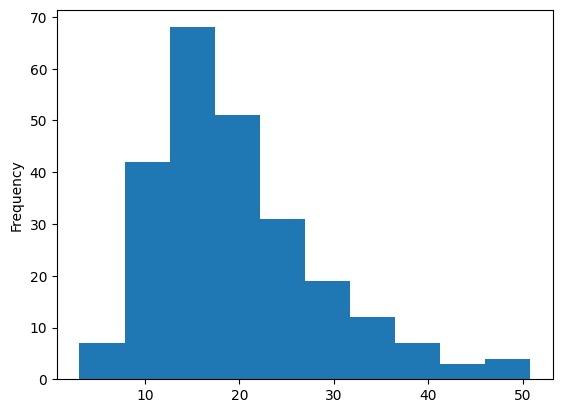

In [19]:
df['total_bill'].plot(kind='hist')

<Axes: ylabel='Frequency'>

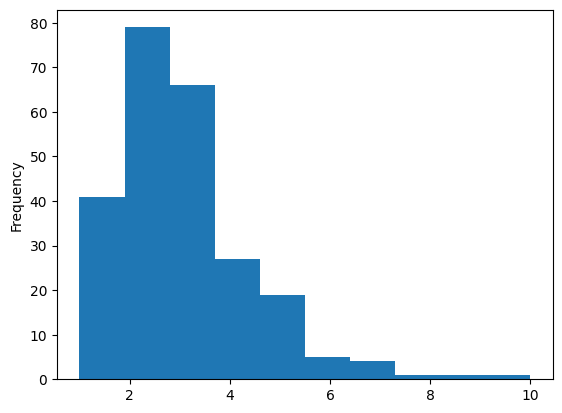

In [20]:
df['tip'].plot(kind='hist')

<Axes: xlabel='day'>

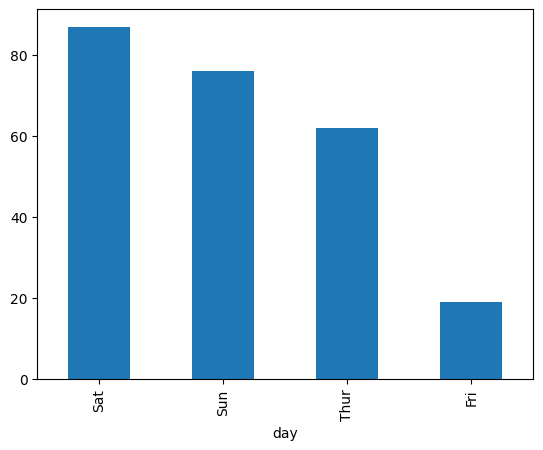

In [21]:
df['day'].value_counts().plot(kind='bar')

<Axes: xlabel='smoker'>

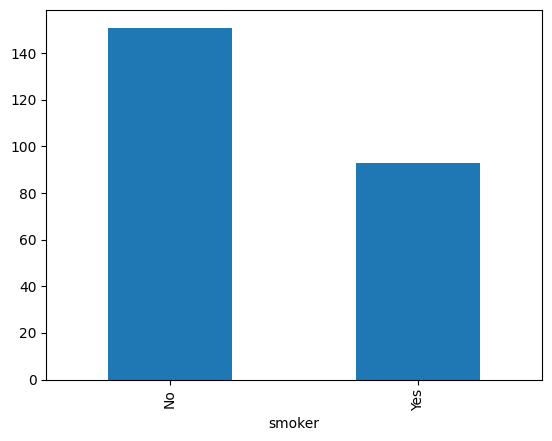

In [22]:
df['smoker'].value_counts().plot(kind='bar')

<Axes: xlabel='sex'>

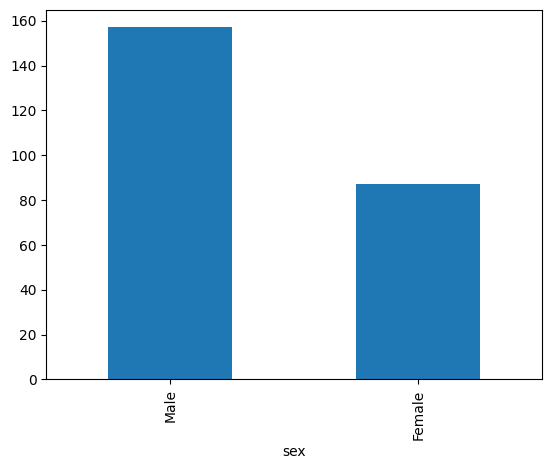

In [23]:
df['sex'].value_counts().plot(kind='bar')

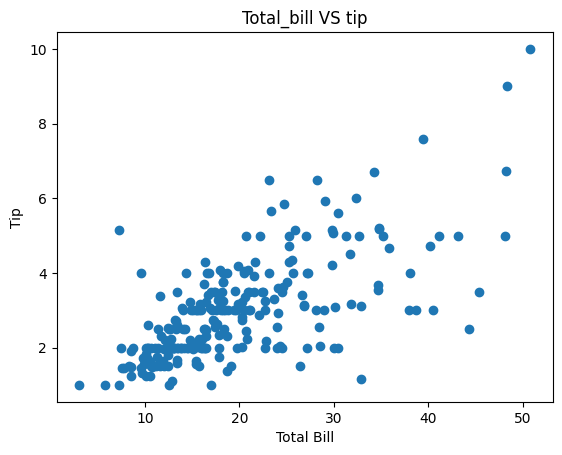

In [24]:
plt.title('Total_bill VS tip')
plt.scatter(df['total_bill'], df['tip'])

plt.xlabel('Total Bill')

plt.ylabel('Tip')

plt.show()

<Axes: xlabel='sex'>

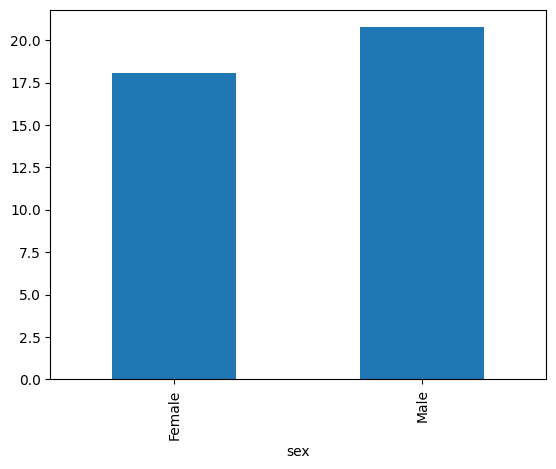

In [25]:
#bill distribution betn male and female
df.groupby('sex')['total_bill'].mean().plot(kind='bar')

<Axes: xlabel='smoker'>

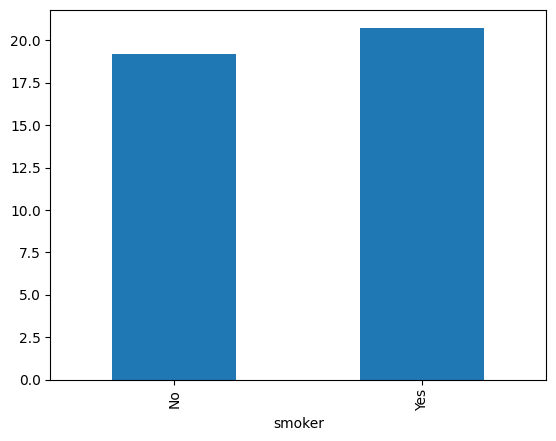

In [26]:
#bill distribution between smoker and non smoker
df.groupby('smoker')['total_bill'].mean().plot(kind='bar')

<Axes: xlabel='day'>

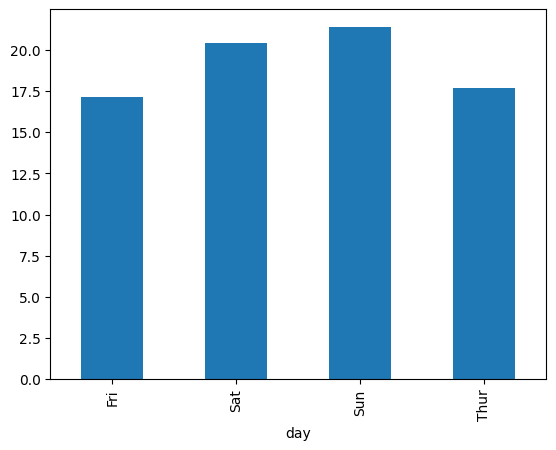

In [27]:
#bill distribution among days
df.groupby('day')['total_bill'].mean().plot(kind='bar')

<Axes: xlabel='time'>

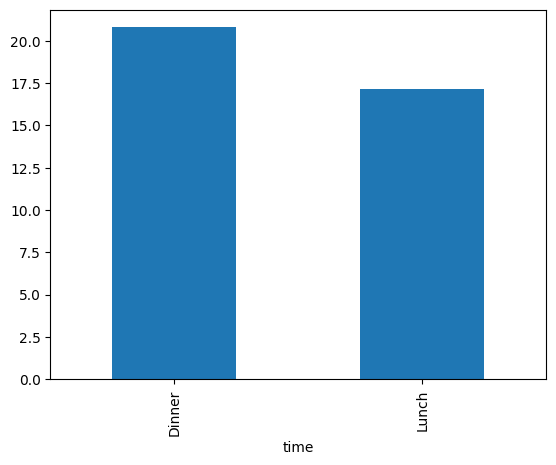

In [28]:
#bill distribution betn time 
df.groupby('time')['total_bill'].mean().plot(kind='bar')

<Axes: xlabel='total_bill', ylabel='tip'>

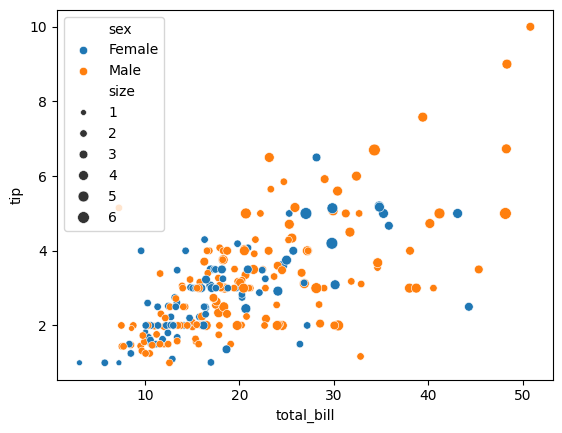

In [29]:
sns.scatterplot(data=df, x='total_bill', y='tip', size='size',hue='sex')  #total bill and sex

<Axes: xlabel='total_bill', ylabel='tip'>

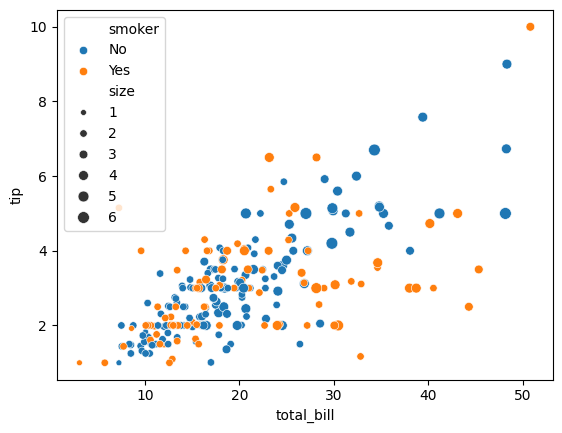

In [30]:
#total bill and smoker
sns.scatterplot(data=df, x='total_bill', y='tip', size='size',hue='smoker')

<Axes: xlabel='total_bill', ylabel='tip'>

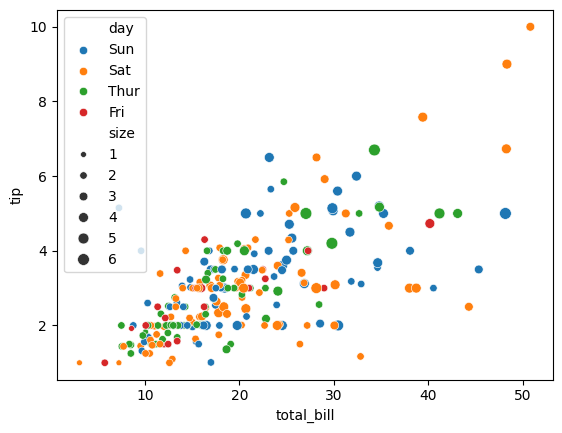

In [31]:
#total bill,tips and day
sns.scatterplot(data=df, x='total_bill', y='tip', size='size',hue='day')


<Axes: xlabel='total_bill', ylabel='tip'>

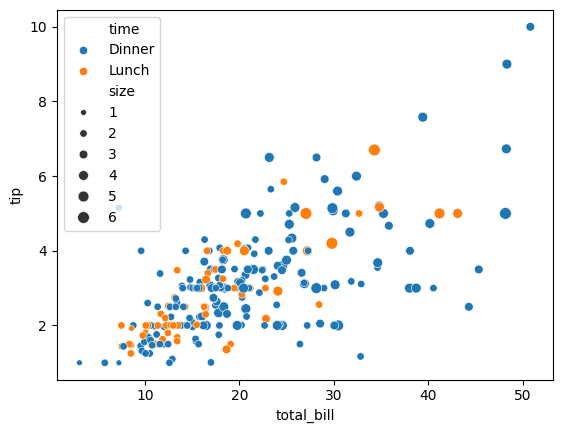

In [32]:
sns.scatterplot(data=df, x='total_bill', y='tip', size='size',hue='time')

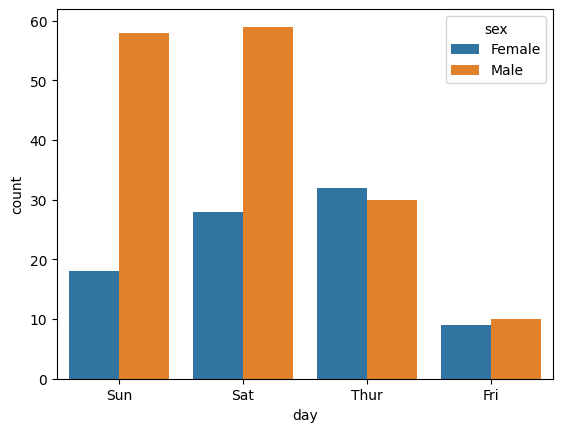

In [33]:
sns.countplot(x='day',data=df,hue='sex')
plt.show()

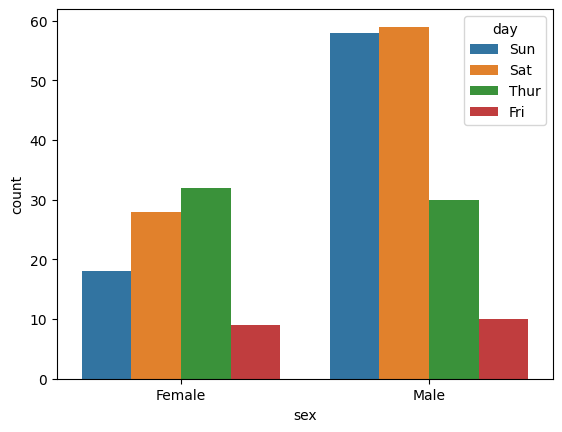

In [34]:
sns.countplot(x='sex',data=df,hue='day')
plt.show()

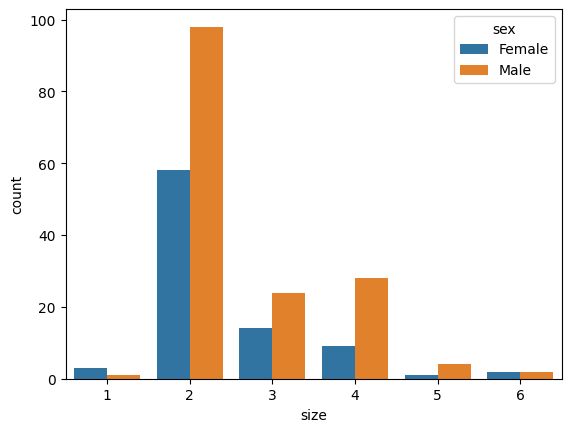

In [35]:
sns.countplot(x='size',data=df,hue='sex')
plt.show()

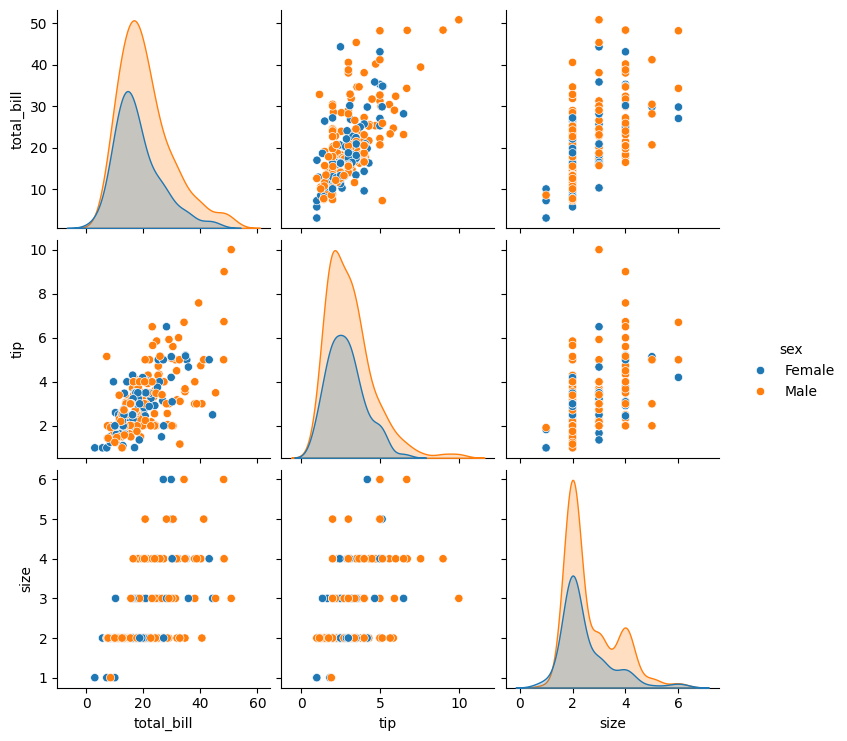

In [36]:
sns.pairplot(data=df,hue='sex')
plt.show()

In [37]:
x=pd.DataFrame(pd.pivot_table(df,index=['sex','smoker'],aggfunc='count')['total_bill'])
x

total_bill
sex    smoker            
Female No              54
       Yes             33
Male   No              97
       Yes             60

In [38]:
x.loc['Female','Yes'].sum()/x.loc['Female'].sum()*100

total_bill    37.931034
dtype: float64

In [39]:
x.loc['Female','No'].sum()/x.loc['Female'].sum()*100

total_bill    62.068966
dtype: float64

In [40]:
(df.groupby(['day','smoker']).count()['total_bill']/df.groupby(['day']).count()['total_bill'])*100

day   smoker
Fri   No        21.052632
      Yes       78.947368
Sat   No        51.724138
      Yes       48.275862
Sun   No        75.000000
      Yes       25.000000
Thur  No        72.580645
      Yes       27.419355
Name: total_bill, dtype: float64

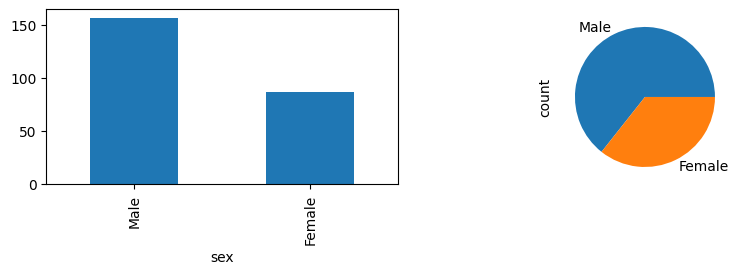

In [41]:
plt.figure(figsize=(10,5))
plt.subplot(2,2,1)
df['sex'].value_counts().plot(kind='bar')
plt.subplot(2,2,2)
df['sex'].value_counts().plot(kind='pie')
plt.show()


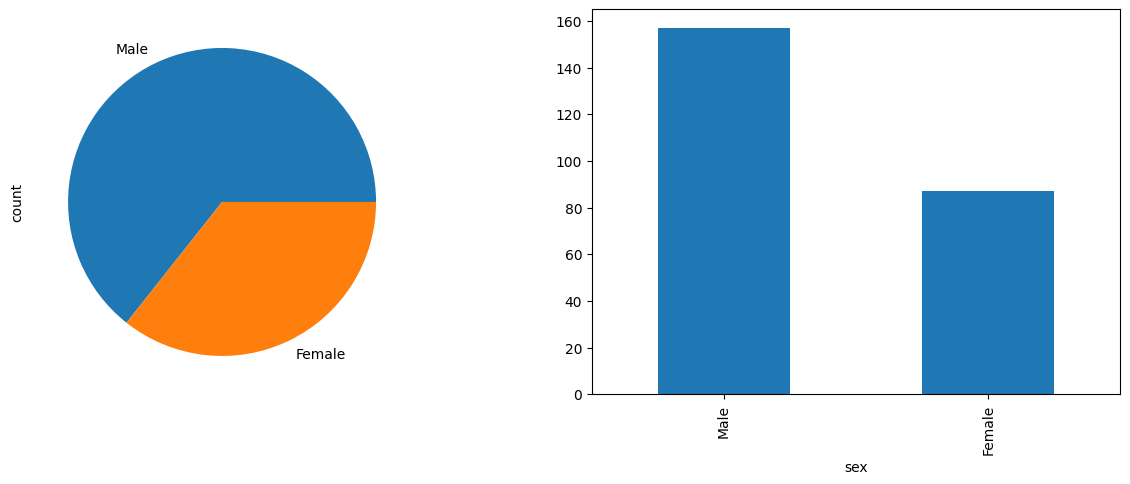

In [42]:
fig, axes=plt.subplots(1,2,figsize=(15,5))
df['sex'].value_counts().plot(kind='bar',ax=axes[1])
df['sex'].value_counts().plot(kind='pie',ax=axes[0])
plt.show()


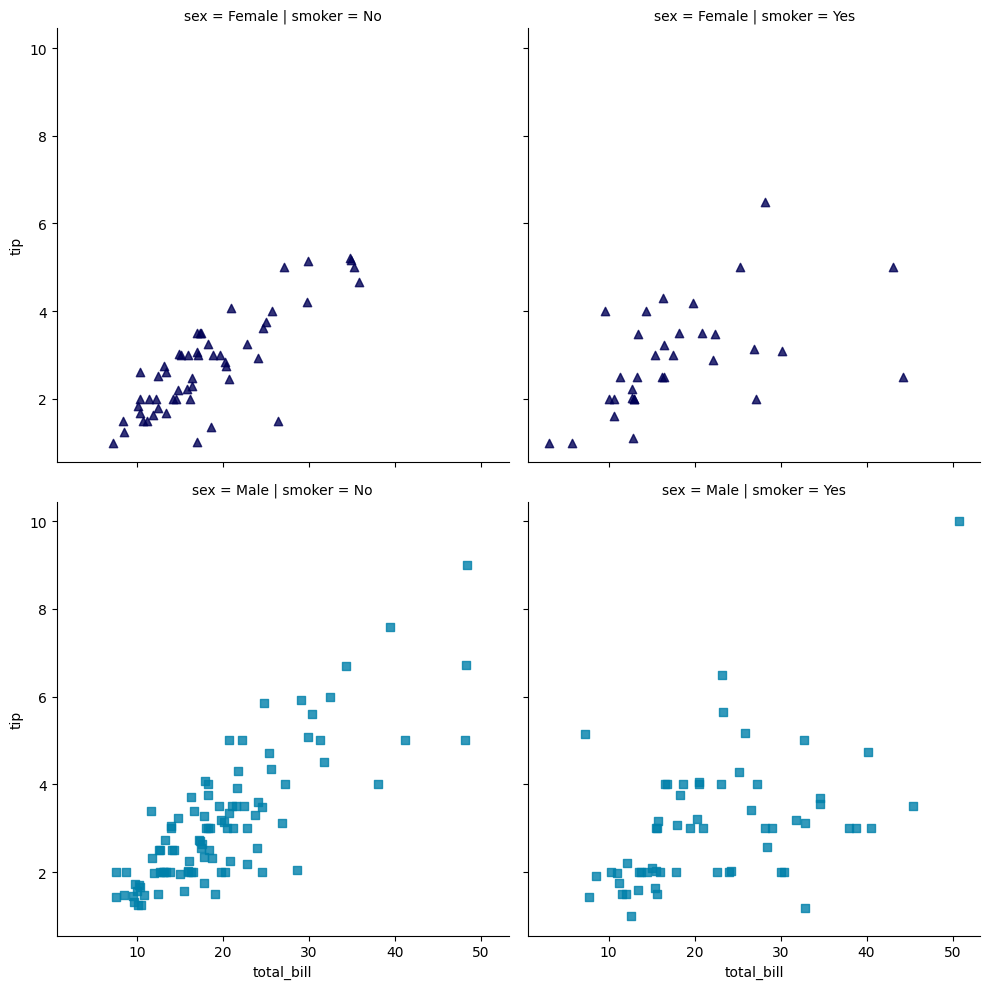

In [43]:
sns.lmplot(x='total_bill',y='tip',data=df,hue='sex',fit_reg=False,markers=['^','s'],palette='ocean',row='sex',col='smoker')
# col and row only for LM plot
plt.show()

In [49]:
sex_le = LabelEncoder()
smoker_le = LabelEncoder()
day_le = LabelEncoder()
time_le = LabelEncoder()


df['sex'] = sex_le.fit_transform(df['sex'])
df['smoker'] = smoker_le.fit_transform(df['smoker'])
df['day'] = day_le.fit_transform(df['day'])
df['time'] = time_le.fit_transform(df['time'])

In [50]:
#splitting the data into x and y
X = df[['total_bill','tip','sex','smoker','day','time']]
y = df['tip']

In [51]:
# Scaling the data
#StandardScaler is a preprocessing module from scikit-learn (sklearn) that standardizes features by removing the mean and scaling to unit variance. It transforms your data such that it has a mean of 0 and a standard deviation of 1.
#This transformation is important when you have features with different scales or units. Standardization ensures that each feature contributes equally to the analysis, preventing features with larger scales from dominating the model.

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [52]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=12)

In [53]:
# Building the model
model = LinearRegression()

# Training the model
model.fit(X_train, y_train)

# Evaluating the model
y_pred = model.predict(X_test)

In [54]:
#Mean Absolute Error (MAE):
Mean Absolute Error (MAE) measures the average absolute difference between the predicted values and the actual values. 
It gives an idea of how wrong the predictions are, on average.
    
mae = mean_absolute_error(y_test, y_pred)

#Mean Squared Error (MSE):
Mean Squared Error (MSE) measures the average squared difference between the predicted values and the actual values.
It amplifies and penalizes large errors more than MAE.
    
mse = mean_squared_error(y_test,y_pred)

#R-squared (R2 Score):
R-squared (R2) is a statistical measure that represents the proportion of the variance in 
the dependent variable (y) that is predictable from the independent variables (X). 
It indicates how well the model captures the variability of the data.
r2 = r2_score(y_test, y_pred)

print('MAE is : ',mae)
print('MSE is : ',mse)
print('R2 is  : ',r2)

MAE is :  2.5376526277146436e-15
MSE is :  1.1168821489736264e-29
R2 is  :  1.0


In [60]:
le = LabelEncoder() 
  
for col in df.columns: 
  if df[col].dtype == object: 
    df[col] = le.fit_transform(df[col]) 
  
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,2,0,2
1,10.34,1.66,1,0,2,0,3
2,21.01,3.50,1,0,2,0,3
3,23.68,3.31,1,0,2,0,2
4,24.59,3.61,0,0,2,0,4


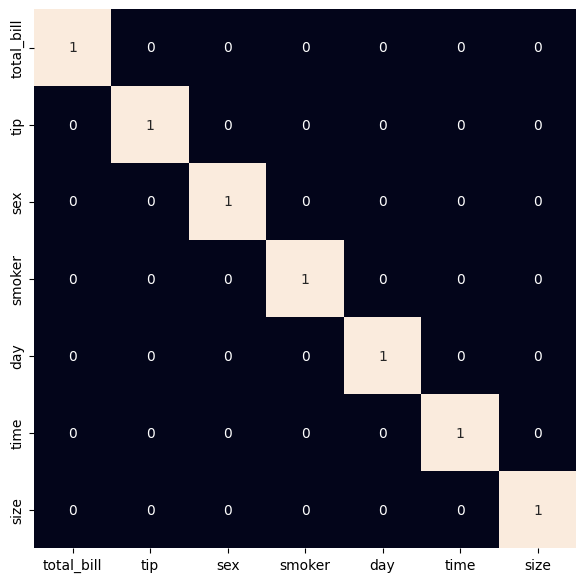

In [64]:

plt.figure(figsize=(7,7)) 
sns.heatmap(df.corr() > 0.7, annot = True, cbar = False) 
plt.show()

In [65]:
features = df.drop('tip', axis=1) 
target = df['tip'] 
  
X_train, X_val, Y_train, Y_val = train_test_split(features, target, test_size=0.2, random_state=22) 
X_train.shape, X_val.shape

((195, 6), (49, 6))

In [9]:
sex_le = LabelEncoder()
smoker_le = LabelEncoder()
day_le = LabelEncoder()
time_le = LabelEncoder()


df['sex'] = sex_le.fit_transform(df['sex'])
df['smoker'] = smoker_le.fit_transform(df['smoker'])
df['day'] = day_le.fit_transform(df['day'])
df['time'] = time_le.fit_transform(df['time'])

In [10]:
# Split the data into X and y
X = df[['total_bill','tip','sex','smoker','day','time']]
y = df['tip']

In [11]:
# Scaling the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [12]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=12)

In [13]:
# Building the model
model = LinearRegression()

# Training the model
model.fit(X_train, y_train)

# Evaluating the model
y_pred = model.predict(X_test)

In [8]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test,y_pred)

r2 = r2_score(y_test, y_pred)

print('MAE is : ',mae)
print('MSE is : ',mse)
print('R2 is  : ',r2)

MAE is :  2.5376526277146436e-15
MSE is :  1.1168821489736264e-29
R2 is  :  1.0
